In [7]:
import pandas as pd
import numpy as np
import os

In [ ]:
os.chdir(r'C:\SML_Projects\SML_gym_fatPercentage_predict_project')

In [ ]:
x_train = pd.read_csv('data/engineered/engineered_x_train.csv')
x_test = pd.read_csv('data/engineered/engineered_x_test.csv')

y_train = pd.read_csv('data/split/y_train.csv')
y_test = pd.read_csv('data/split/y_test.csv')

In [10]:
train_df = pd.concat([x_train, y_train], axis=1)
test_df = pd.concat([x_test, y_test], axis=1)

df = pd.concat([train_df, test_df], axis=0, ignore_index=True)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         973 non-null    float64
 1   gender                      973 non-null    object 
 2   weight                      973 non-null    float64
 3   height                      973 non-null    float64
 4   max_bpm                     973 non-null    float64
 5   avg_bpm                     973 non-null    float64
 6   resting_bpm                 973 non-null    float64
 7   session_duration            973 non-null    float64
 8   calories_burned             973 non-null    float64
 9   workout_type                973 non-null    object 
 10  water_intake                973 non-null    float64
 11  workout_frequency           973 non-null    float64
 12  experience_level            973 non-null    float64
 13  bmi                         973 non

In [12]:
df_fixed = df.copy()

numeric_features = df_fixed.select_dtypes(include=['int64', 'float64'])

target = df_fixed['fat_percentage']

pearson_corr = numeric_features.corrwith(target)
print("=== Pearson correlation with fat_percentage ===\n", pearson_corr)

spearman_corr = numeric_features.corrwith(target, method='spearman')
print("\n=== Spearman correlation with fat_percentage ===\n", spearman_corr)

=== Pearson correlation with fat_percentage ===
 age                           0.002370
weight                       -0.225512
height                       -0.235521
max_bpm                      -0.009056
avg_bpm                      -0.007302
resting_bpm                  -0.016834
session_duration             -0.581520
calories_burned              -0.597615
water_intake                 -0.588683
workout_frequency            -0.537060
experience_level             -0.654363
bmi                          -0.119258
hrr                           0.001413
intensity                    -0.003400
cardio_load                  -0.453758
weekly_cardio_load           -0.608594
bpm_efficiency               -0.633516
calories_per_min             -0.171970
calories_per_kg              -0.269840
fat_burn_efficiency          -0.070786
weight_height_ratio          -0.180332
bmi_age_interaction          -0.076807
weight_age_ratio             -0.127976
fat_risk_score               -0.126738
water_per_sessi

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         973 non-null    float64
 1   gender                      973 non-null    object 
 2   weight                      973 non-null    float64
 3   height                      973 non-null    float64
 4   max_bpm                     973 non-null    float64
 5   avg_bpm                     973 non-null    float64
 6   resting_bpm                 973 non-null    float64
 7   session_duration            973 non-null    float64
 8   calories_burned             973 non-null    float64
 9   workout_type                973 non-null    object 
 10  water_intake                973 non-null    float64
 11  workout_frequency           973 non-null    float64
 12  experience_level            973 non-null    float64
 13  bmi                         973 non

In [14]:
from scipy.stats import f_oneway

target_col = 'fat_percentage'

categorical_features = df.select_dtypes(include=['object']).columns

df_fixed = df.copy()

anova_results = {}

for col in categorical_features:
    if col == target_col:  
        continue

    groups = [df_fixed[df_fixed[col] == val][target_col] 
              for val in df_fixed[col].unique()]

    valid_groups = [g for g in groups if len(g) > 1]

    if len(valid_groups) > 1:
        f_stat, p_val = f_oneway(*valid_groups)
        anova_results[col] = {'F-statistic': f_stat, 'p-value': p_val}

anova_df = pd.DataFrame(anova_results).T.sort_values('p-value')
print("\nANOVA Results for Categorical Features vs fat_percentage:\n")
print(anova_df)


ANOVA Results for Categorical Features vs fat_percentage:

                 F-statistic       p-value
weight_category   124.356034  3.852122e-68
gender            193.130301  3.525662e-40
bmi_category        5.591767  1.883615e-04
workout_type        1.894962  1.287503e-01
age_category        0.136742  9.380964e-01


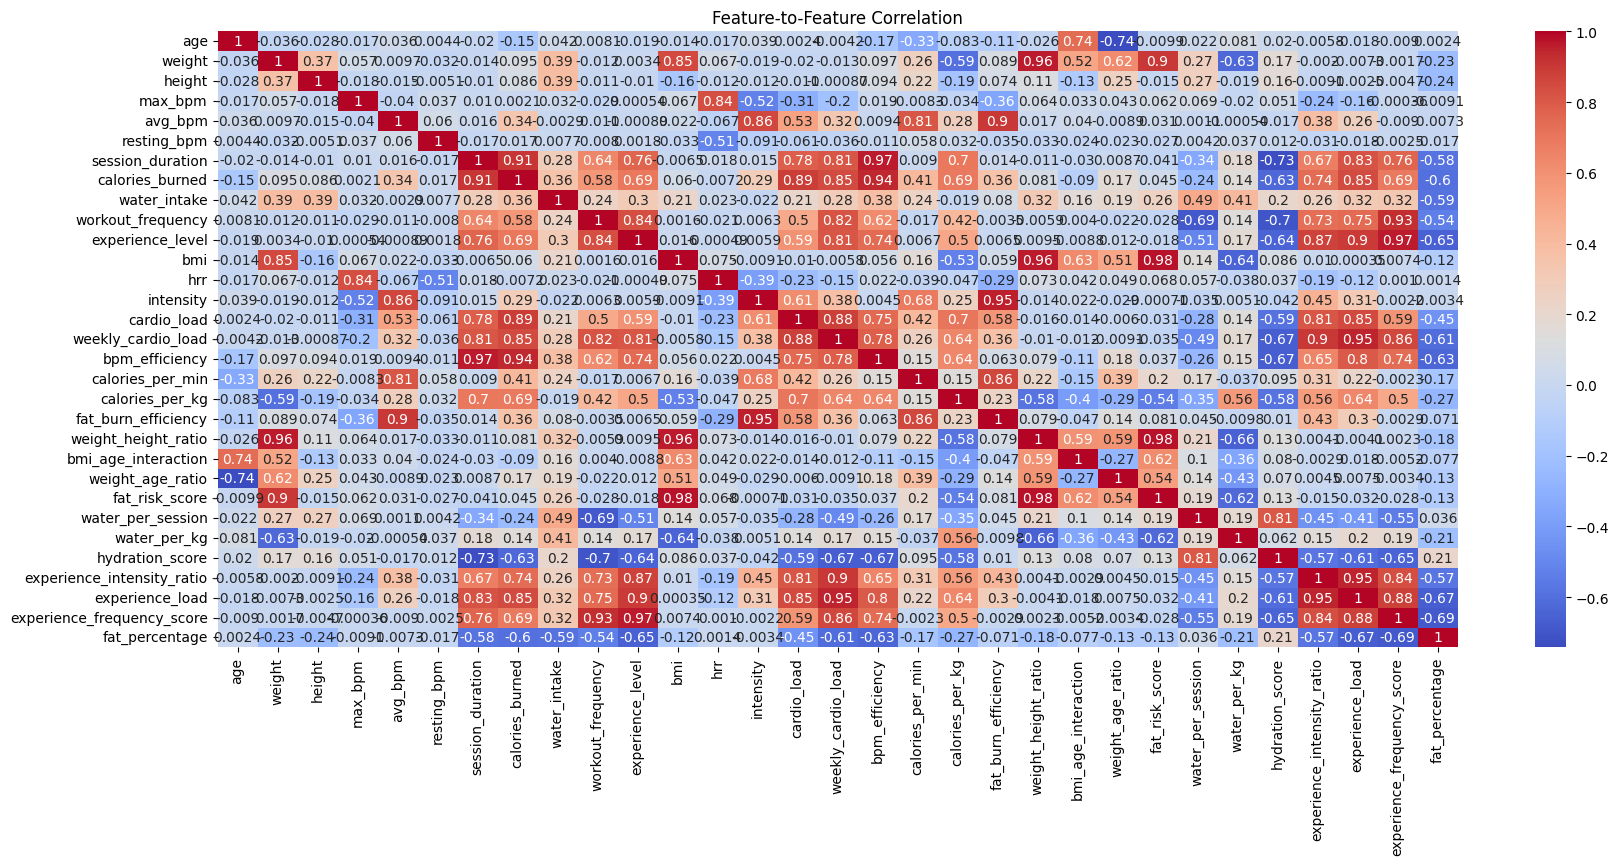

Highly correlated features to drop: ['calories_burned', 'bpm_efficiency', 'fat_burn_efficiency', 'weight_height_ratio', 'fat_risk_score', 'experience_intensity_ratio', 'experience_load', 'experience_frequency_score']


In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(20,8))
sns.heatmap(df[numeric_features.columns].corr(), annot=True, cmap='coolwarm')
plt.title("Feature-to-Feature Correlation")
plt.show()

corr_matrix = df[numeric_features.columns].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]
print("Highly correlated features to drop:", to_drop)

In [16]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)  
selector.fit(df[numeric_features.columns])

low_variance_features = numeric_features.columns[~selector.get_support()]
print("Low variance features (to drop):", list(low_variance_features))

Low variance features (to drop): ['water_per_kg']


In [18]:
from sklearn.feature_selection import mutual_info_regression

mi = mutual_info_regression(df[numeric_features.columns], df['fat_percentage'])
mi_series = pd.Series(mi, index=numeric_features.columns).sort_values()

print("Features ranked by mutual information:\n")
print(mi_series)

low_mi_threshold = 0.01

features_to_drop = list(mi_series[mi_series < low_mi_threshold].index)

print("\n=== FEATURES TO DROP (BY MUTUAL INFORMATION) ===")
for f in features_to_drop:
    print(f)

df_cleaned = df.drop(columns=features_to_drop)

Features ranked by mutual information:

max_bpm                       0.000000
hrr                           0.000000
fat_burn_efficiency           0.009024
resting_bpm                   0.012317
intensity                     0.023055
bmi_age_interaction           0.024473
age                           0.024837
weight_age_ratio              0.051324
avg_bpm                       0.056661
bmi                           0.087107
fat_risk_score                0.131126
calories_per_min              0.131634
height                        0.150528
cardio_load                   0.164234
calories_per_kg               0.175295
weight_height_ratio           0.202798
weekly_cardio_load            0.273529
workout_frequency             0.287986
experience_intensity_ratio    0.295031
water_per_kg                  0.300072
calories_burned               0.305133
hydration_score               0.331844
experience_load               0.385476
bpm_efficiency                0.385825
session_duration        

In [19]:
categorical_features = df.select_dtypes(include=['object']).columns

low_info_cats = []

for col in categorical_features:
    top_freq = df[col].value_counts(normalize=True).iloc[0]
    if top_freq > 0.80:   
        low_info_cats.append(col)

print("Low-information categorical features:", low_info_cats)

Low-information categorical features: []


In [20]:
skew_check = x_train.select_dtypes(include=['float64'])
skew_check.skew()

age                          -0.074672
weight                        0.784176
height                        0.289078
max_bpm                      -0.057106
avg_bpm                       0.077491
resting_bpm                  -0.063779
session_duration              0.004109
calories_burned               0.279007
water_intake                  0.050545
workout_frequency             0.156558
experience_level              0.316327
bmi                           0.753211
hrr                          -0.013948
intensity                     0.315968
cardio_load                   0.418180
weekly_cardio_load            0.909500
bpm_efficiency                0.135186
calories_per_min              0.225340
calories_per_kg               0.353249
fat_burn_efficiency           0.463099
weight_height_ratio           0.765061
bmi_age_interaction           0.910742
weight_age_ratio              1.420528
fat_risk_score                1.483398
water_per_session             1.208283
water_per_kg             

In [ ]:
skewness = skew_check.skew()
log_transformation = skewness[(skewness>=0.5)].index.tolist()

log_transformation

['weight',
 'bmi',
 'weekly_cardio_load',
 'weight_height_ratio',
 'bmi_age_interaction',
 'weight_age_ratio',
 'fat_risk_score',
 'water_per_session',
 'hydration_score',
 'experience_intensity_ratio',
 'experience_load',
 'experience_frequency_score']